# **1. Installing & Importing Libraries**

In [2]:
!pip install rdkit torch torch_geometric seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.2 MB/s eta 0:00:00


In [3]:
import os
import csv
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import time
import traceback
import matplotlib.pyplot as plt
from rdkit import Chem
import math
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import negative_sampling
from torch_geometric.nn import GATConv
from sklearn.metrics import roc_auc_score, auc, precision_recall_curve
from torch.optim.lr_scheduler import MultiplicativeLR
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve
)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# Set seed for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# **2.Datasets Loading**

In [5]:
combinedgraph = pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Datasets/Edited Dataset/FDIGraph.csv")
combinedgraph

,src,dst
0,D00572,F00001
1,D00230,F00001
2,D01002,F00001
3,D00065,F00001
4,D00265,F00001
...,...,...
20175,D00937,F00269
20176,D00181,F00269
20177,D00193,F00269
20178,D00773,F00269


In [30]:
Embedding_models = {
    'T5': (pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Embeddings/T5_Descriptions_Embeddings.csv"), combinedgraph),
    'Bert': (pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Embeddings/BERT_Embeddings.csv"), combinedgraph),
    'SBert': (pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Embeddings/SBERT_Embeddings.csv"), combinedgraph),
    'Chemberta': (pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Embeddings/Chemberta_Embeddings.csv"), combinedgraph)
}

# **3. Graph Creation**

In [6]:
# Graph Analysis
G = nx.from_pandas_edgelist(combinedgraph, source='src', target='dst')

print("Graph Summary")
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"Isolated Nodes: {any(deg == 0 for _, deg in G.degree())}")
print(f"Self-loops: {any(G.has_edge(n, n) for n in G.nodes())}")

Graph Summary
Nodes: 2462 | Edges: 15022
Isolated Nodes: False
Self-loops: False


In [7]:
# Convert to PyTorch Geometric format
def prepare_pyg_data(features, graph):

    unique_ids = np.unique(graph.values)
    id_map = {name: i for i, name in enumerate(unique_ids)}

    src = graph['src'].map(id_map).values
    dst = graph['dst'].map(id_map).values
    edge_index = torch.tensor(np.vstack((np.concatenate([src, dst]), np.concatenate([dst, src]))), dtype=torch.long)

    # Sanitize features: convert to DataFrame, drop string columns, keep only numeric
    if not isinstance(features, pd.DataFrame):
        features = pd.DataFrame(features)

    # Drop common identifier/non-numeric columns
    features = features.select_dtypes(include=[np.number])  # Keep only numeric

    # Final clean up and conversion
    features = np.nan_to_num(features.values.astype(np.float32))
    x = torch.tensor(features, dtype=torch.float32)

    return Data(x=x, edge_index=edge_index)

# **4. GAT Model**

In [8]:
class GATNet(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()

        self.gat1 = GATConv(in_channels, hidden, heads=4, dropout=0.3)
        self.gat2 = GATConv(hidden * 4, hidden, heads=2, dropout=0.3)
        self.gat3 = GATConv(hidden * 2, hidden, heads=1, dropout=0.3)

        self.lin1 = nn.Linear(hidden * 2, hidden)
        self.lin2 = nn.Linear(hidden, 1)

    def encode(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = self.gat3(x, edge_index)
        return x

    def decode(self, z, edge_index):
        h = torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=1)
        h = F.relu(self.lin1(h))
        return self.lin2(h).view(-1)

# **5. Training & Evaluation**

In [9]:
def train(model, optimizer, criterion, data):
    model.train()
    optimizer.zero_grad()

    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index)

    loss = criterion(out, data.edge_label)
    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).sigmoid()

    auc_score = roc_auc_score(
        data.edge_label.cpu().numpy(),
        out.cpu().numpy()
    )
    return auc_score, out.cpu().numpy(), data.edge_label.cpu().numpy()

In [11]:
def plot_roc_per_lr(roc_dict, lr):
    plt.figure(figsize=(7, 7))

    for model_name, (scores, labels) in roc_dict.items():
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Comparison (LR = {lr})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


===== Learning Rate: 0.001 =====
Training T5
Epoch 010 | Loss 0.2449 | Val AUC 0.9579
Epoch 020 | Loss 0.1801 | Val AUC 0.9666
Epoch 030 | Loss 0.1651 | Val AUC 0.9620
Epoch 040 | Loss 0.1506 | Val AUC 0.9711
Epoch 050 | Loss 0.1345 | Val AUC 0.9774
Epoch 060 | Loss 0.1313 | Val AUC 0.9802
Final Results | T5 | LR=0.001 | Val AUC=0.9802 | Test AUC=0.9798 | PR AUC=0.9800
Training Bert
Epoch 010 | Loss 0.2414 | Val AUC 0.9550
Epoch 020 | Loss 0.1839 | Val AUC 0.9620
Epoch 030 | Loss 0.1470 | Val AUC 0.9691
Epoch 040 | Loss 0.1229 | Val AUC 0.9775
Epoch 050 | Loss 0.1069 | Val AUC 0.9808
Epoch 060 | Loss 0.1143 | Val AUC 0.9811
Final Results | Bert | LR=0.001 | Val AUC=0.9815 | Test AUC=0.9842 | PR AUC=0.9861
Training SBert
Epoch 010 | Loss 0.2635 | Val AUC 0.9525
Epoch 020 | Loss 0.1855 | Val AUC 0.9722
Epoch 030 | Loss 0.1364 | Val AUC 0.9802
Epoch 040 | Loss 0.1304 | Val AUC 0.9814
Epoch 050 | Loss 0.1112 | Val AUC 0.9855
Epoch 060 | Loss 0.1062 | Val AUC 0.9852
Final Results | SBert |

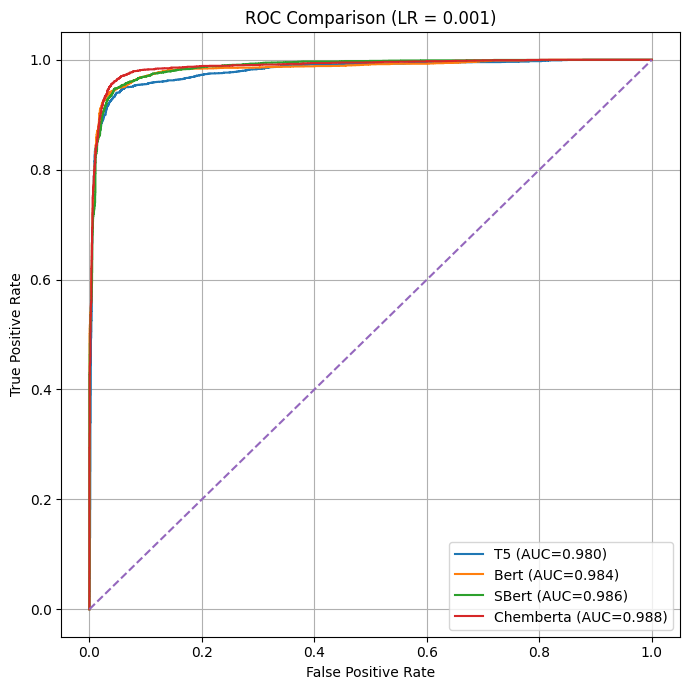


===== Learning Rate: 0.0005 =====
Training T5
Epoch 010 | Loss 0.2969 | Val AUC 0.9539
Epoch 020 | Loss 0.2256 | Val AUC 0.9678
Epoch 030 | Loss 0.1846 | Val AUC 0.9768
Epoch 040 | Loss 0.1495 | Val AUC 0.9809
Epoch 050 | Loss 0.1401 | Val AUC 0.9840
Epoch 060 | Loss 0.1257 | Val AUC 0.9872
Final Results | T5 | LR=0.0005 | Val AUC=0.9872 | Test AUC=0.9861 | PR AUC=0.9878
Training Bert
Epoch 010 | Loss 0.2708 | Val AUC 0.9462
Epoch 020 | Loss 0.1916 | Val AUC 0.9555
Epoch 030 | Loss 0.1450 | Val AUC 0.9609
Epoch 040 | Loss 0.1307 | Val AUC 0.9677
Epoch 050 | Loss 0.1216 | Val AUC 0.9711
Epoch 060 | Loss 0.1095 | Val AUC 0.9765
Final Results | Bert | LR=0.0005 | Val AUC=0.9768 | Test AUC=0.9774 | PR AUC=0.9806
Training SBert
Epoch 010 | Loss 0.2710 | Val AUC 0.9566
Epoch 020 | Loss 0.2004 | Val AUC 0.9714
Epoch 030 | Loss 0.1559 | Val AUC 0.9790
Epoch 040 | Loss 0.1393 | Val AUC 0.9784
Epoch 050 | Loss 0.1248 | Val AUC 0.9814
Epoch 060 | Loss 0.1239 | Val AUC 0.9823
Final Results | SBer

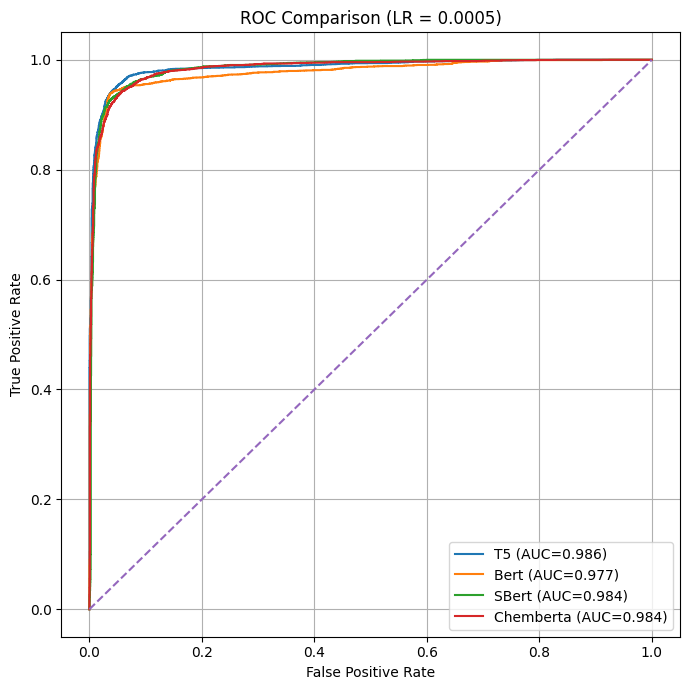


===== Learning Rate: 0.0001 =====
Training T5
Epoch 010 | Loss 0.4868 | Val AUC 0.9491
Epoch 020 | Loss 0.3201 | Val AUC 0.9613
Epoch 030 | Loss 0.2577 | Val AUC 0.9671
Epoch 040 | Loss 0.2227 | Val AUC 0.9725
Epoch 050 | Loss 0.2102 | Val AUC 0.9741
Epoch 060 | Loss 0.1933 | Val AUC 0.9756
Final Results | T5 | LR=0.0001 | Val AUC=0.9756 | Test AUC=0.9747 | PR AUC=0.9726
Training Bert
Epoch 010 | Loss 0.4155 | Val AUC 0.9536
Epoch 020 | Loss 0.3097 | Val AUC 0.9520
Epoch 030 | Loss 0.2751 | Val AUC 0.9555
Epoch 040 | Loss 0.2405 | Val AUC 0.9598
Epoch 050 | Loss 0.2145 | Val AUC 0.9630
Epoch 060 | Loss 0.1822 | Val AUC 0.9650
Final Results | Bert | LR=0.0001 | Val AUC=0.9650 | Test AUC=0.9640 | PR AUC=0.9696
Training SBert
Epoch 010 | Loss 0.5335 | Val AUC 0.9510
Epoch 020 | Loss 0.3745 | Val AUC 0.9599
Epoch 030 | Loss 0.2854 | Val AUC 0.9624
Epoch 040 | Loss 0.2498 | Val AUC 0.9608
Epoch 050 | Loss 0.2347 | Val AUC 0.9625
Epoch 060 | Loss 0.2132 | Val AUC 0.9642
Final Results | SBer

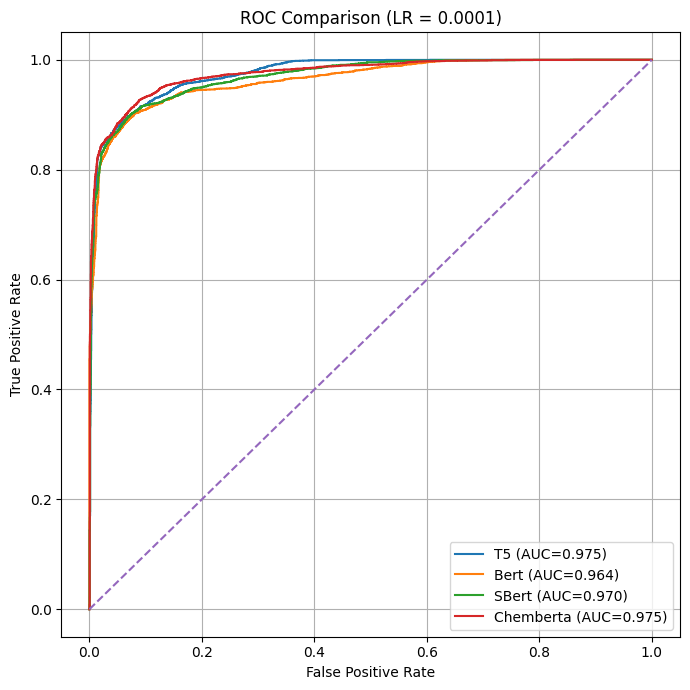


Training completed successfully.


In [13]:
RESULTS_PATH = "/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Processed/GATNet_Results.csv"

# Create CSV with header if it does not exist
if not os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Model",
            "Learning Rate",
            "Best Validation AUC",
            "Final Test AUC",
            "PR AUC"
        ])

lr_list = [0.001, 0.0005, 0.0001]
epochs = 60

lr_roc_results = {}

for lr in lr_list:
    print(f"\n===== Learning Rate: {lr} =====")
    lr_roc_results[lr] = {}

    for model_name, (features, graph) in Embedding_models.items():
        print(f"Training {model_name}")

        # -------- Feature Processing --------
        features = features.select_dtypes(include=[np.number])
        features = StandardScaler().fit_transform(features.values)
        features = torch.tensor(features, dtype=torch.float32)

        data = prepare_pyg_data(features, graph)

        transform = RandomLinkSplit(
            is_undirected=True,
            add_negative_train_samples=True,
            neg_sampling_ratio=1.0
        )

        train_data, val_data, test_data = transform(data)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        train_data = train_data.to(device)
        val_data = val_data.to(device)
        test_data = test_data.to(device)

        model = GATNet(train_data.num_features, 128).to(device)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=5e-4
        )

        criterion = nn.BCEWithLogitsLoss()

        best_val_auc = 0.0
        final_test_auc = 0.0
        best_scores, best_labels = None, None

        # -------- Training Loop --------
        for epoch in range(1, epochs + 1):
            loss = train(model, optimizer, criterion, train_data)
            val_auc, _, _ = evaluate(model, val_data)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                final_test_auc, scores, labels = evaluate(model, test_data)
                best_scores, best_labels = scores, labels

            if epoch % 10 == 0:
                print(
                    f"Epoch {epoch:03d} | "
                    f"Loss {loss:.4f} | "
                    f"Val AUC {val_auc:.4f}"
                )

        # -------- PR AUC --------
        pr_auc = 0.0
        if best_scores is not None and len(np.unique(best_labels)) > 1:
            precision, recall, _ = precision_recall_curve(best_labels, best_scores)
            pr_auc = auc(recall, precision)

        # -------- Save ROC data for plotting --------
        lr_roc_results[lr][model_name] = (best_scores, best_labels)

        # -------- SAVE RESULTS TO CSV --------
        with open(RESULTS_PATH, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                model_name,
                lr,
                best_val_auc,
                final_test_auc,
                pr_auc
            ])

        print(
            f"Final Results | {model_name} | "
            f"LR={lr} | "
            f"Val AUC={best_val_auc:.4f} | "
            f"Test AUC={final_test_auc:.4f} | "
            f"PR AUC={pr_auc:.4f}"
        )

    # -------- ROC PLOT (ALL MODELS @ THIS LR) --------
    plot_roc_per_lr(lr_roc_results[lr], lr)

print("\nTraining completed successfully.")


# **6. Visualisation**

In [22]:
Results = "/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Processed/GATNet_Results.csv"


df = pd.read_csv(Results)

df.columns = [
    "Model",
    "Learning Rate",
    "Best Val AUC",
    "Test AUROC",
    "Test AUPR"
]

df = df.drop_duplicates(
    subset=["Model", "Learning Rate"],
    keep="last"
)

**1. AUROC**

In [23]:
auc_table = df.pivot(
    index="Model",
    columns="Learning Rate",
    values="Test AUROC"
).reset_index()

auc_table.to_csv(
    "/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Processed/Final_AUROC_Table.csv",
    index=False
)

**2. AUPR**

In [24]:
pr_table = df.pivot(
    index="Model",
    columns="Learning Rate",
    values="Test AUPR"
).reset_index()

pr_table.to_csv(
    "/content/drive/MyDrive/VRSEC/IV Year/Major/Sahith/Processed/Final_AUPR_Table.csv",
    index=False
)

**3. Best Model per LR**

In [26]:
best_models = df.sort_values(
    by="Test AUPR",
    ascending=False
).groupby("Model").head(1)

**4. AUROC Bar Plot**

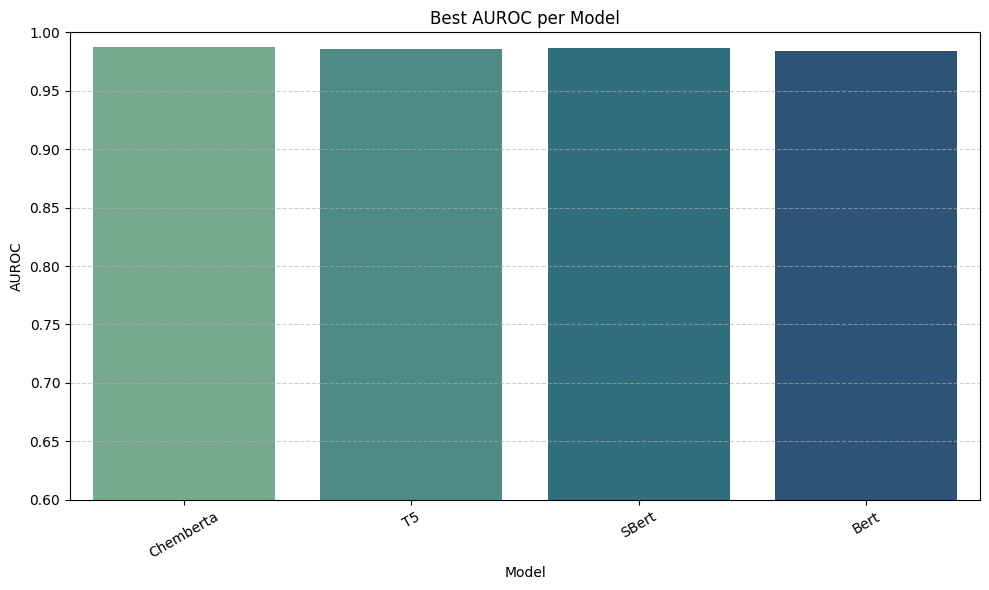

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=best_models,
    x="Model",
    y="Test AUROC",
    palette="crest"
)

plt.title("Best AUROC per Model")
plt.ylabel("AUROC")
plt.ylim(0.6, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**5. AUPR Bar Plot**

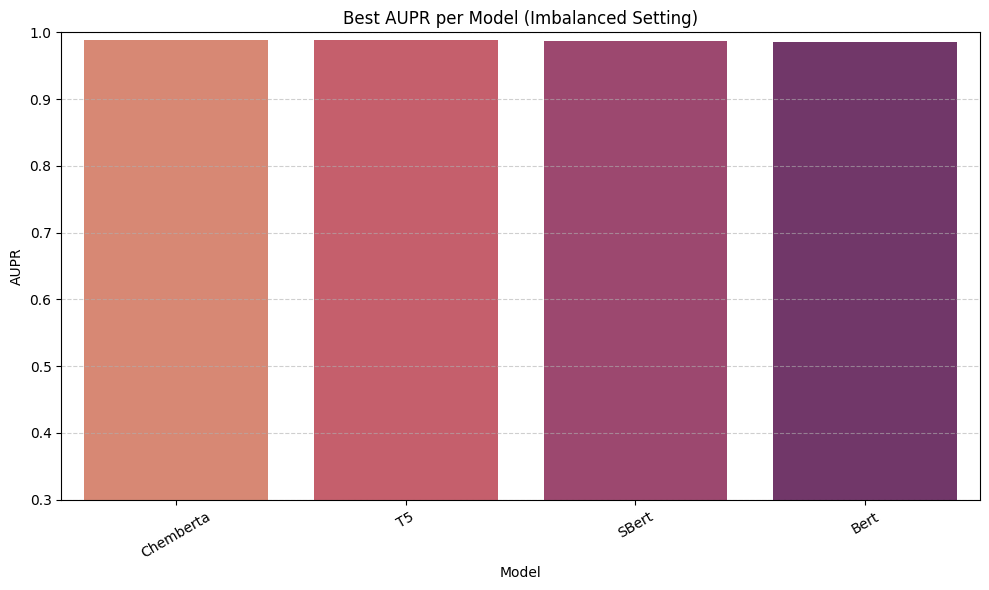

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=best_models,
    x="Model",
    y="Test AUPR",
    palette="flare"
)

plt.title("Best AUPR per Model (Imbalanced Setting)")
plt.ylabel("AUPR")
plt.ylim(0.3, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

AUPR & Learning Rate

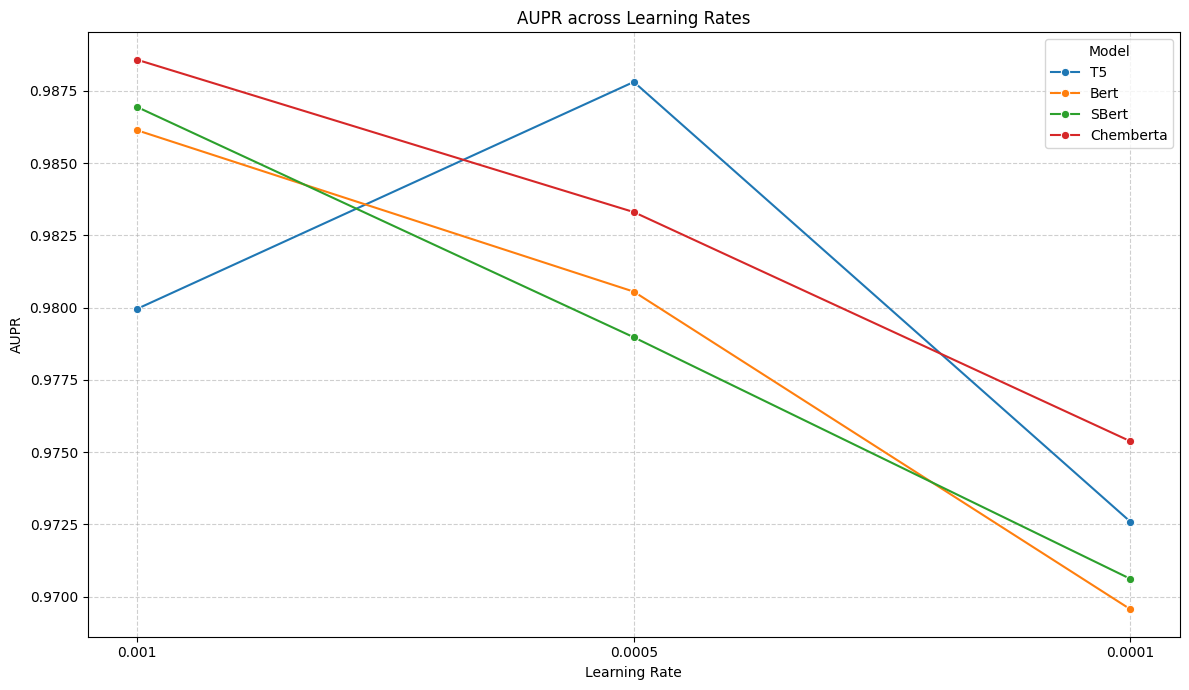

In [29]:
df["Learning Rate"] = df["Learning Rate"].astype(str)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df,
    x="Learning Rate",
    y="Test AUPR",
    hue="Model",
    marker="o"
)

plt.title("AUPR across Learning Rates")
plt.xlabel("Learning Rate")
plt.ylabel("AUPR")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Model")
plt.tight_layout()
plt.show()